# Causal Inductive Bias Test for TCN and UTCN Models

This notebook demonstrates the causal inductive bias by testing TCN and UTCN models with step function inputs. A truly causal model should only respond to inputs at the current time step and earlier, not future inputs.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from self_interferometry.analysis.tcn import TCN, TCNConfig
from self_interferometry.analysis.utcn import UTCN, UTCNConfig

## Model Configuration

Create configurations for both TCN and UTCN models based on the project configs.

In [2]:
# Common parameters
sequence_length = 256
input_channels = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# TCN configuration
tcn_config = TCNConfig(
    sequence_length=sequence_length,
    in_channels=input_channels,
    activation="GELU",
    layer_norm=True,
    kernel_size=7,
    num_channels=[16, 32, 64, 128],  # Simplified for testing
    dilation_base=2,
)

# UTCN configuration
utcn_config = UTCNConfig(
    sequence_length=sequence_length,
    in_channels=input_channels,
    activation="GELU",
    layer_norm=True,
    kernel_size=7,
    n_layers=7,
    utcn_out_channels=[64, 32, 16, 8, 16, 32, 64],
    utcn_dilations=[1, 2, 4, 8, 4, 2, 1],
    horizontal_skips_map=None,  # Uses default symmetric skips
    horizontal_skip="linear",
)

print(f"TCN config: {tcn_config}")
print(f"UTCN config: {utcn_config}")

Using device: cpu
TCN config: TCNConfig(sequence_length=256, in_channels=3, activation='GELU', layer_norm=True, kernel_size=7, num_channels=[16, 32, 64, 128], dilation_base=2)
UTCN config: UTCNConfig(sequence_length=256, in_channels=3, activation='GELU', layer_norm=True, kernel_size=7, n_layers=7, utcn_out_channels=[64, 32, 16, 8, 16, 32, 64], utcn_dilations=[1, 2, 4, 8, 4, 2, 1], horizontal_skips_map=None, horizontal_skip='linear')


## Model Initialization

Initialize both models and move them to the appropriate device.

In [3]:
# Initialize models
tcn_model = TCN(tcn_config).to(device)
utcn_model = UTCN(utcn_config).to(device)

# Set models to evaluation mode
tcn_model.eval()
utcn_model.eval()

# Count parameters
tcn_params = sum(p.numel() for p in tcn_model.parameters() if p.requires_grad)
utcn_params = sum(p.numel() for p in utcn_model.parameters() if p.requires_grad)

print(f"TCN parameters: {tcn_params:,}")
print(f"UTCN parameters: {utcn_params:,}")

TCN parameters: 240,279
UTCN parameters: 197,993


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


## Causal Bias Test Function

This function creates step function inputs where a block of ones moves from left to right in the sequence. A causal model should only show responses that begin at or after the step location.

In [4]:
def test_causal_bias(model, model_name, step_positions=None, block_size=32):
    """
    Test causal inductive bias by creating step function inputs.
    
    Args:
        model: The neural network model to test
        model_name: Name for plotting
        step_positions: List of positions where the step occurs
        block_size: Size of the block of ones
    
    Returns:
        inputs: Input sequences [n_steps, channels, sequence_length]
        outputs: Model outputs [n_steps, sequence_length]
    """
    if step_positions is None:
        step_positions = range(0, sequence_length - block_size, 16)
    
    n_steps = len(step_positions)+1
    
    # Store inputs and outputs
    inputs = torch.zeros(n_steps, input_channels, sequence_length, device=device)
    outputs = torch.zeros(n_steps, sequence_length, device=device)
    
    with torch.no_grad():
        for i in range(n_steps):
            # This line sets step_pos -1 at the end to make input_seq all zeros
            step_pos = step_positions[i] if i < len(step_positions) else -1
            # Create step function: zeros before step_pos, ones after
            input_seq = torch.zeros(1, input_channels, sequence_length, device=device)
            if step_pos >= 0:
                input_seq[:, :, step_pos:step_pos + block_size] = 1.0
            
            # Forward pass
            output = model(input_seq)
            
            # Store results
            inputs[i] = input_seq[0]
            outputs[i] = output[0, 0]  # First batch, first channel
    
    return inputs, outputs

## Run Causal Bias Tests

Test both models with step function inputs to visualize their causal behavior.

In [5]:
# Define step positions for testing
step_positions = list(range(0, sequence_length - 32, 8))
print(f"Testing {len(step_positions)} step positions")

# Test TCN model
print("Testing TCN model...")
tcn_inputs, tcn_outputs = test_causal_bias(tcn_model, "TCN", step_positions)

# Test UTCN model
print("Testing UTCN model...")
utcn_inputs, utcn_outputs = test_causal_bias(utcn_model, "UTCN", step_positions)

print("Testing complete!")

Testing 28 step positions
Testing TCN model...
Testing UTCN model...
Testing complete!


## Visualization

Create visualizations to show the causal behavior of both models. In a truly causal system, the output should only change after the input step, creating a pattern where responses appear on or below the diagonal.

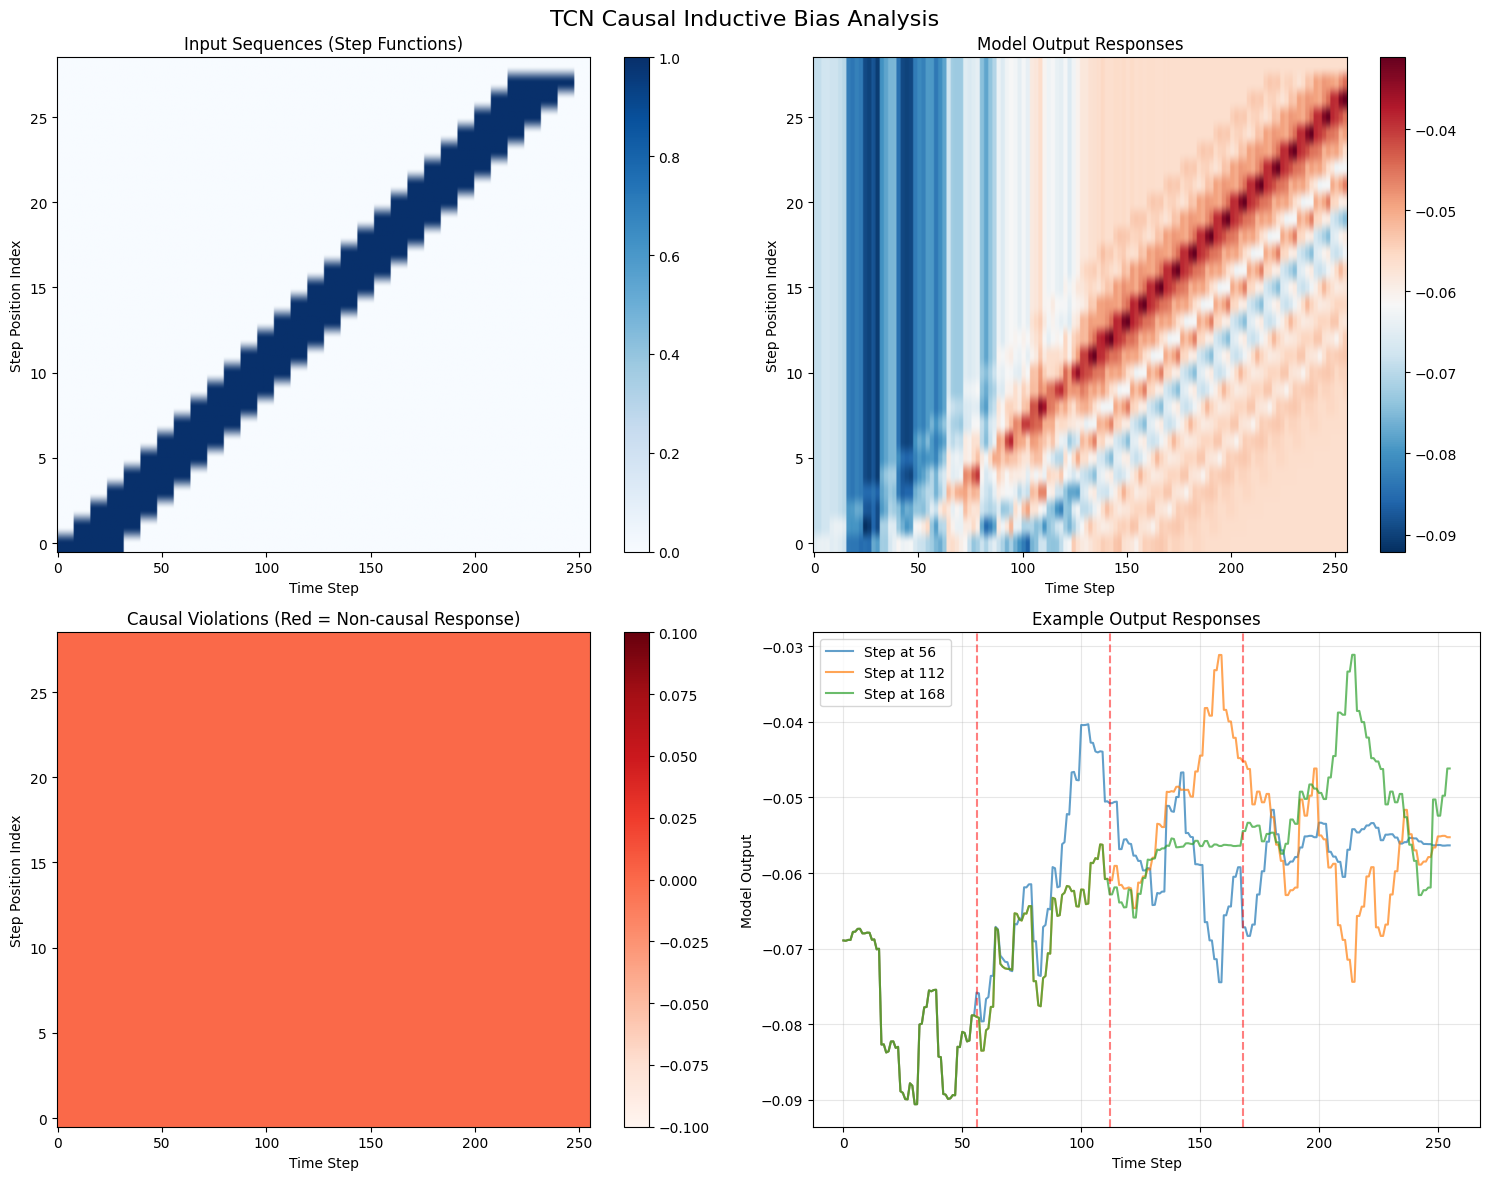

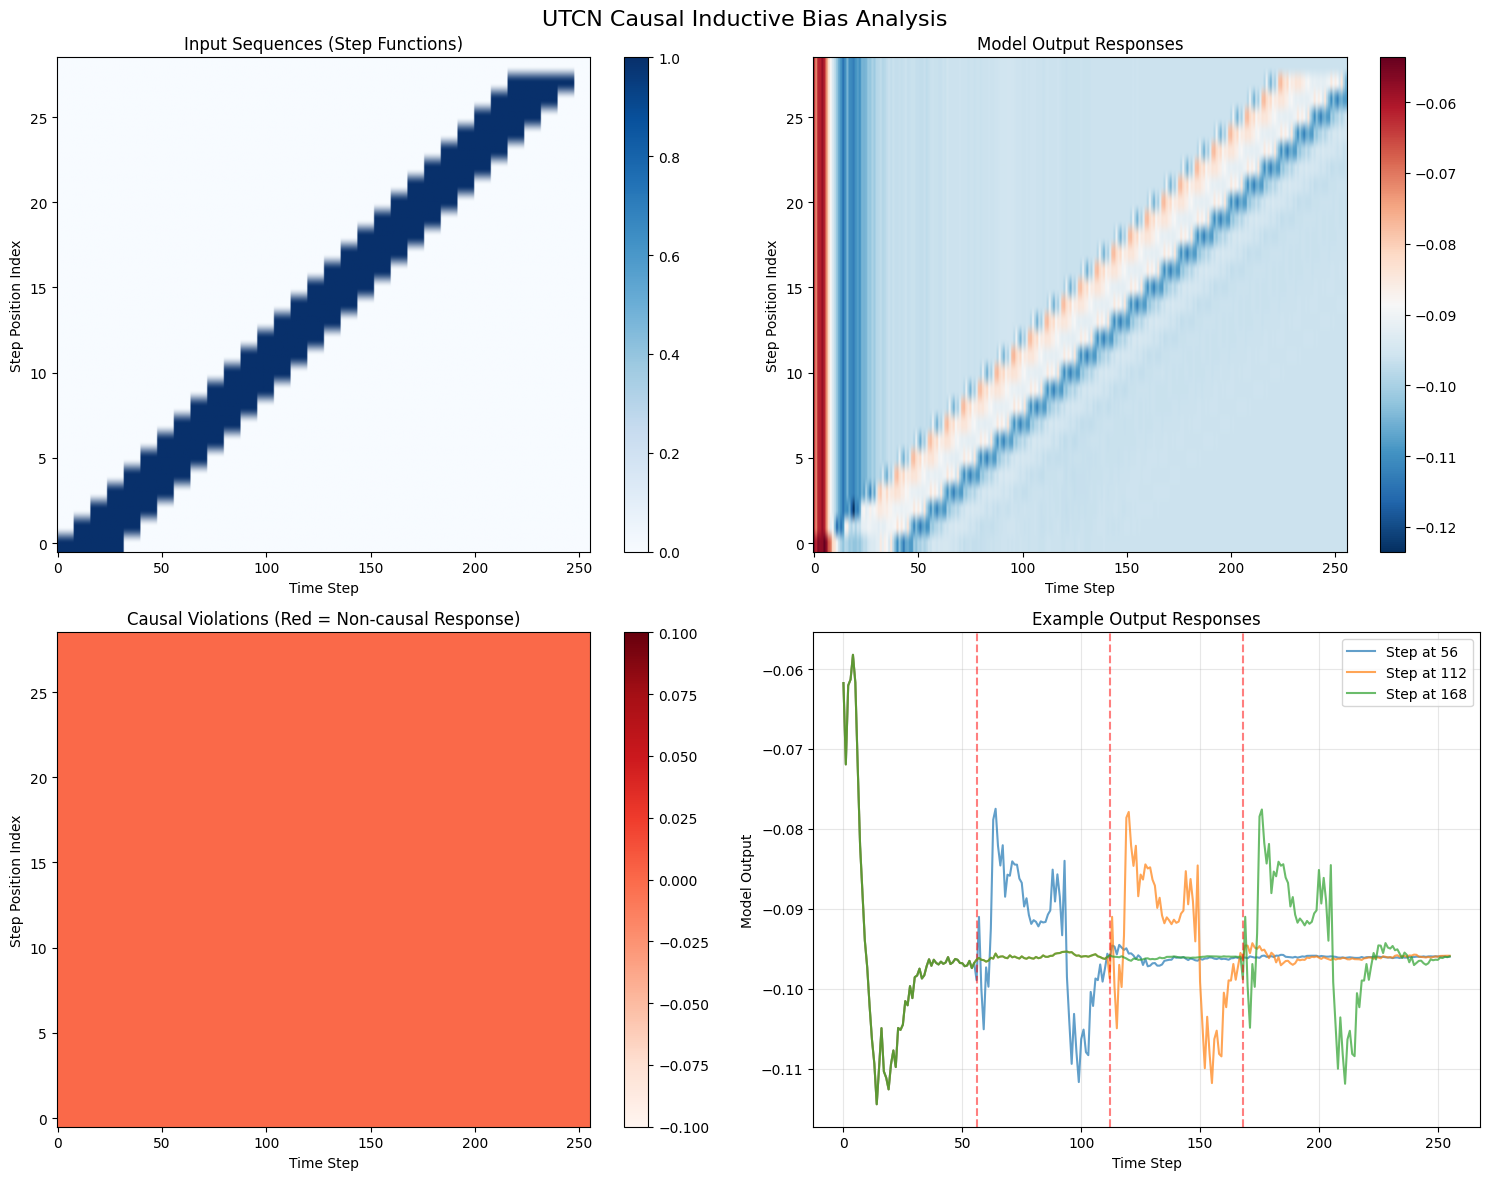

In [6]:
def plot_causal_response(inputs, outputs, step_positions, model_name):
    """
    Plot the causal response matrix showing input vs output relationships.
    
    Args:
        inputs: Input sequences
        outputs: Model outputs
        step_positions: Positions of step functions
        model_name: Name for the plot title
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'{model_name} Causal Inductive Bias Analysis', fontsize=16)
    
    # Convert to numpy for plotting
    inputs_np = inputs[:, 0].cpu().numpy()  # Use first channel
    outputs_np = outputs.cpu().numpy()
    
    # Plot 1: Input patterns
    im1 = axes[0, 0].imshow(inputs_np, aspect='auto', cmap='Blues', origin='lower')
    axes[0, 0].set_title('Input Sequences (Step Functions)')
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('Step Position Index')
    plt.colorbar(im1, ax=axes[0, 0])
    
    # Plot 2: Output responses
    im2 = axes[0, 1].imshow(outputs_np, aspect='auto', cmap='RdBu_r', origin='lower')
    axes[0, 1].set_title('Model Output Responses')
    axes[0, 1].set_xlabel('Time Step')
    axes[0, 1].set_ylabel('Step Position Index')
    plt.colorbar(im2, ax=axes[0, 1])
    
    # Plot 3: Causal violation detection
    # For each step position, check if output changes before the step
    causal_matrix = np.zeros_like(outputs_np)
    
    for i, step_pos in enumerate(step_positions):
        # Output should be zero (or baseline) before step_pos for causal behavior
        baseline = outputs_np[-1, :step_pos] if step_pos > 0 else 0
        
        # Check for significant deviation from baseline before step
        if step_pos > 0:
            pre_step_response = np.abs(outputs_np[i, :step_pos] - baseline)
            threshold = 0.1 * np.abs(outputs_np[i, step_pos:]).max()  # 10% of max response
            
            # Mark violations (responses before the step)
            causal_matrix[i, :step_pos] = pre_step_response > threshold
    
    im3 = axes[1, 0].imshow(causal_matrix, aspect='auto', cmap='Reds', origin='lower')
    axes[1, 0].set_title('Causal Violations (Red = Non-causal Response)')
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].set_ylabel('Step Position Index')
    plt.colorbar(im3, ax=axes[1, 0])
    
    # Plot 4: Example responses for specific step positions
    example_indices = [len(step_positions)//4, len(step_positions)//2, 3*len(step_positions)//4]
    
    for idx in example_indices:
        if idx < len(step_positions):
            step_pos = step_positions[idx]
            axes[1, 1].plot(outputs_np[idx], label=f'Step at {step_pos}', alpha=0.7)
            axes[1, 1].axvline(x=step_pos, color='red', linestyle='--', alpha=0.5)
    
    axes[1, 1].set_title('Example Output Responses')
    axes[1, 1].set_xlabel('Time Step')
    axes[1, 1].set_ylabel('Model Output')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Create visualizations for both models
tcn_fig = plot_causal_response(tcn_inputs, tcn_outputs, step_positions, "TCN")
plt.show()

utcn_fig = plot_causal_response(utcn_inputs, utcn_outputs, step_positions, "UTCN")
plt.show()

## Quantitative Causal Analysis

Calculate metrics to quantify the degree of causal violation in each model.

In [10]:
def calculate_causal_metrics(outputs, step_positions, model_name):
    """
    Calculate quantitative metrics for causal behavior.
    
    Args:
        outputs: Model outputs tensor
        step_positions: List of step positions
        model_name: Name of the model
    
    Returns:
        dict: Dictionary of causal metrics
    """
    outputs_np = outputs.cpu().numpy()
    metrics = {}
    
    total_violations = 0
    total_positions = 0
    max_violation_strength = 0
    
    for i, step_pos in enumerate(step_positions):
        if step_pos == 0:
            continue  # Skip first position
            
        # Calculate baseline (average of all-zero input response)
        baseline = outputs_np[-1, :step_pos]
        
        # Calculate post-step response magnitude
        post_step_response = outputs_np[i, step_pos:]
        max_response = np.abs(post_step_response).max()
        
        if max_response > 1e-6:  # Only analyze if there's significant response
            # Pre-step response (should be close to baseline for causal models)
            pre_step_response = outputs_np[i, :step_pos]
            pre_step_deviation = np.abs(pre_step_response - baseline)
            
            # Define violation threshold as 5% of max response
            threshold = 0.05 * max_response
            violations = pre_step_deviation > threshold
            
            # Count violations
            total_violations += violations.sum()
            total_positions += len(pre_step_deviation)
            
            # Track maximum violation strength
            if violations.any():
                violation_strength = (pre_step_deviation[violations] / max_response).max()
                max_violation_strength = max(max_violation_strength, violation_strength)
    
    # Calculate metrics
    violation_rate = total_violations / total_positions if total_positions > 0 else 0
    causality_score = 1 - violation_rate  # Higher is more causal
    
    metrics = {
        'model_name': model_name,
        'violation_rate': violation_rate,
        'causality_score': causality_score,
        'max_violation_strength': max_violation_strength,
        'total_violations': total_violations,
        'total_positions': total_positions
    }
    
    return metrics

# Calculate metrics for both models
tcn_metrics = calculate_causal_metrics(tcn_outputs, step_positions, "TCN")
utcn_metrics = calculate_causal_metrics(utcn_outputs, step_positions, "UTCN")

# Print results
print("\n" + "="*60)
print("CAUSAL INDUCTIVE BIAS ANALYSIS RESULTS")
print("="*60)

for metrics in [tcn_metrics, utcn_metrics]:
    print(f"\n{metrics['model_name']} Model:")
    print(f"  Causality Score: {metrics['causality_score']:.4f} (higher is more causal)")
    print(f"  Violation Rate: {metrics['violation_rate']:.4f} ({metrics['violation_rate']*100:.2f}%)")
    print(f"  Max Violation Strength: {metrics['max_violation_strength']:.4f}")
    print(f"  Total Violations: {metrics['total_violations']}/{metrics['total_positions']}")

# Compare models
print(f"\nComparison:")
if tcn_metrics['causality_score'] > utcn_metrics['causality_score']:
    diff = tcn_metrics['causality_score'] - utcn_metrics['causality_score']
    print(f"TCN shows better causal behavior (Δ = {diff:.4f})")
elif utcn_metrics['causality_score'] > tcn_metrics['causality_score']:
    diff = utcn_metrics['causality_score'] - tcn_metrics['causality_score']
    print(f"UTCN shows better causal behavior (Δ = {diff:.4f})")
else:
    print("Both models show similar causal behavior")


CAUSAL INDUCTIVE BIAS ANALYSIS RESULTS

TCN Model:
  Causality Score: 1.0000 (higher is more causal)
  Violation Rate: 0.0000 (0.00%)
  Max Violation Strength: 0.0000
  Total Violations: 0/3024

UTCN Model:
  Causality Score: 1.0000 (higher is more causal)
  Violation Rate: 0.0000 (0.00%)
  Max Violation Strength: 0.0000
  Total Violations: 0/3024

Comparison:
Both models show similar causal behavior


## Detailed Step Response Analysis

Examine specific step responses to understand the models' causal behavior in detail.

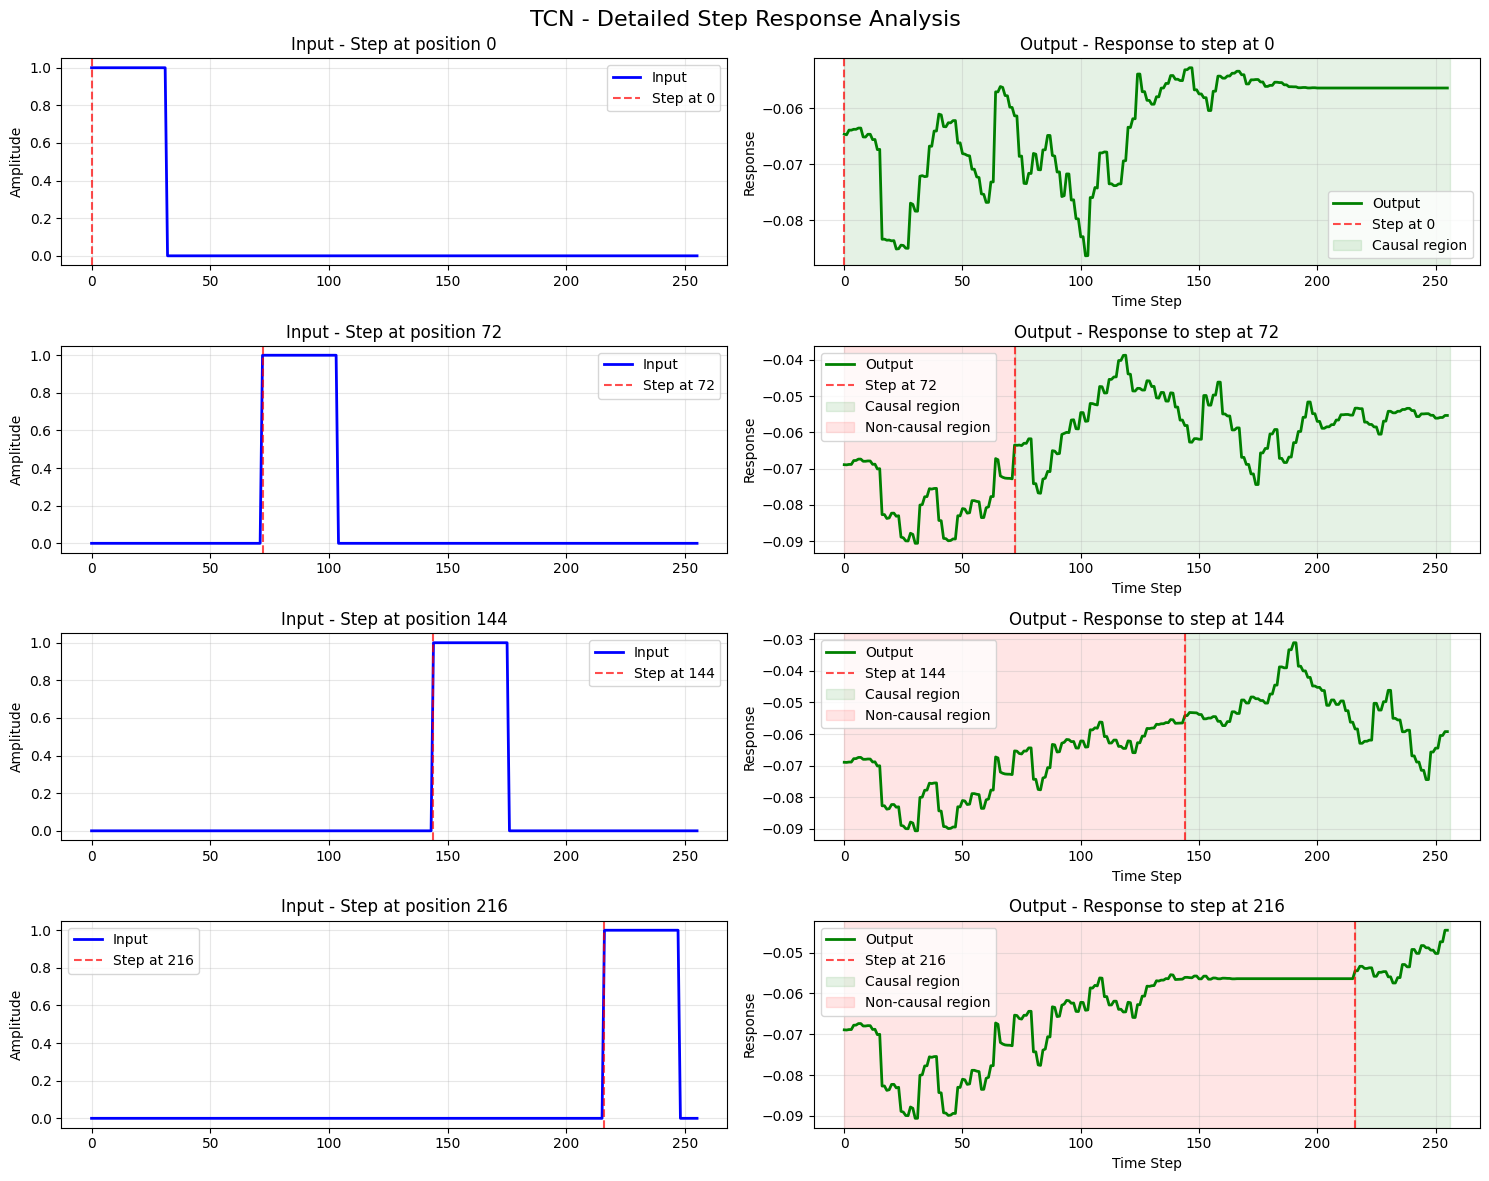

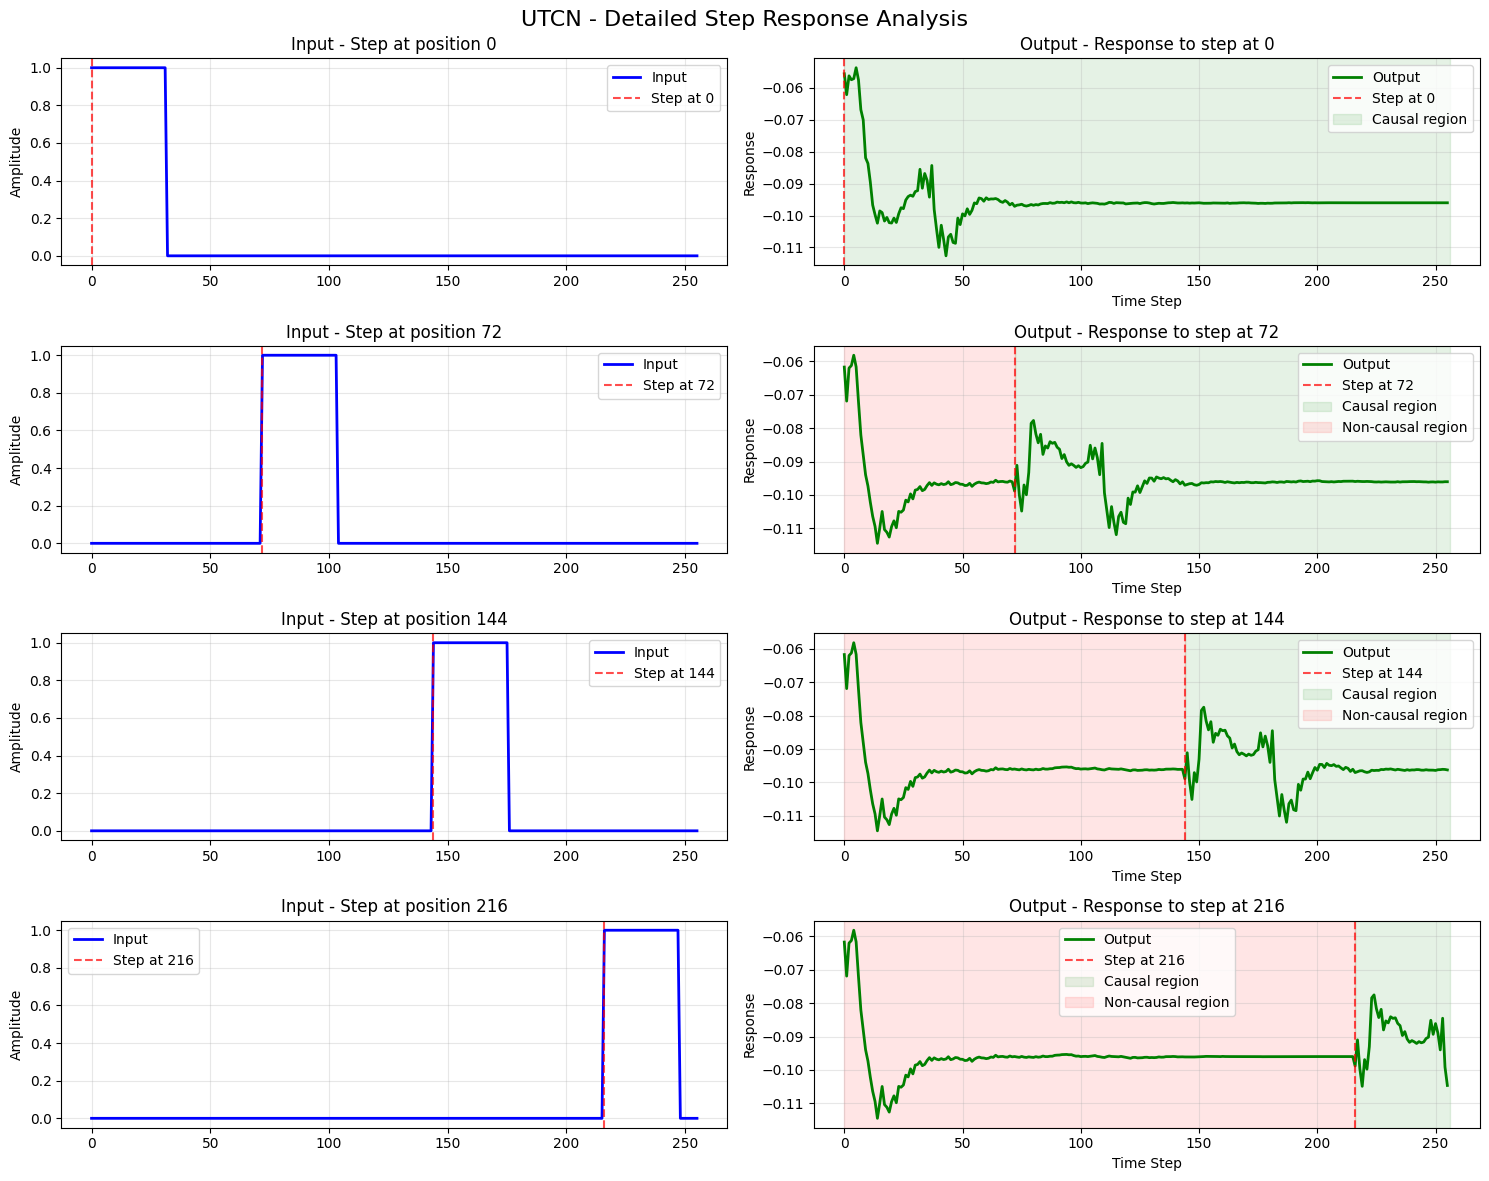

In [8]:
def plot_detailed_step_responses(inputs, outputs, step_positions, model_name, num_examples=4):
    """
    Plot detailed step responses for specific examples.
    """
    fig, axes = plt.subplots(num_examples, 2, figsize=(15, 3*num_examples))
    fig.suptitle(f'{model_name} - Detailed Step Response Analysis', fontsize=16)
    
    inputs_np = inputs[:, 0].cpu().numpy()  # First channel
    outputs_np = outputs.cpu().numpy()
    
    # Select evenly spaced examples
    example_indices = np.linspace(0, len(step_positions)-1, num_examples, dtype=int)
    
    for i, idx in enumerate(example_indices):
        step_pos = step_positions[idx]
        
        # Plot input
        axes[i, 0].plot(inputs_np[idx], 'b-', linewidth=2, label='Input')
        axes[i, 0].axvline(x=step_pos, color='red', linestyle='--', alpha=0.7, label=f'Step at {step_pos}')
        axes[i, 0].set_title(f'Input - Step at position {step_pos}')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()
        
        # Plot output
        axes[i, 1].plot(outputs_np[idx], 'g-', linewidth=2, label='Output')
        axes[i, 1].axvline(x=step_pos, color='red', linestyle='--', alpha=0.7, label=f'Step at {step_pos}')
        
        # Highlight causal region
        axes[i, 1].axvspan(step_pos, sequence_length, alpha=0.1, color='green', label='Causal region')
        if step_pos > 0:
            axes[i, 1].axvspan(0, step_pos, alpha=0.1, color='red', label='Non-causal region')
        
        axes[i, 1].set_title(f'Output - Response to step at {step_pos}')
        axes[i, 1].set_ylabel('Response')
        axes[i, 1].set_xlabel('Time Step')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()
    
    plt.tight_layout()
    return fig

# Create detailed plots for both models
tcn_detail_fig = plot_detailed_step_responses(tcn_inputs, tcn_outputs, step_positions, "TCN")
plt.show()

utcn_detail_fig = plot_detailed_step_responses(utcn_inputs, utcn_outputs, step_positions, "UTCN")
plt.show()

## Summary and Conclusions

This notebook tests the causal inductive bias of TCN and UTCN models by analyzing their responses to step function inputs. Key observations:

1. **Causal Behavior**: A truly causal model should only respond at or after the input step position
2. **Non-causal Violations**: Responses that occur before the step indicate non-causal behavior
3. **Architecture Differences**: Compare how the U-Net structure (UTCN) affects causality vs standard TCN

The visualizations show:
- Input step functions moving through time
- Model output responses 
- Causal violation detection (responses before the step)
- Quantitative metrics comparing the models

This analysis helps understand whether these architectures maintain temporal causality, which is important for real-time applications and interpretability.